# Fashion Brand Collaboration Analysis - Data Visualization

## Objective
Analyze fashion brand data using visualizations to identify trends, brand performance, sustainability, engagement, and collaboration opportunities.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_excel("../data/final_brand_recommendation_dataset.xlsx")

df.head()

,Brand,Category,Country,Followers_Million,Engagement_Rate,Avg_Price_USD,Sustainability,Target_Audience,Global_Stores,Trend_Score,Collaboration_Count,Collaboration_Score,Sustainability_Score,Category_Code,Audience_Code
0,Nike,Sportswear,USA,27,1.90,166,High,Young Adults,3549,83,9,41.35,3,8,2
1,Adidas,Sportswear,Germany,60,2.63,98,Medium,Adults,4118,86,19,55.57,2,8,0
2,Puma,Sportswear,Germany,79,2.86,88,Medium,Young Adults,1217,75,13,40.98,2,8,2
3,Zara,Fast Fashion,Spain,22,1.35,46,High,Adults,681,84,12,30.99,3,2,0
4,H&M,Fast Fashion,Sweden,15,1.72,65,High,Adults,2386,92,6,42.58,3,2,0


In [3]:
df.shape

(101, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Brand                 101 non-null    object 
 1   Category              101 non-null    object 
 2   Country               101 non-null    object 
 3   Followers_Million     101 non-null    int64  
 4   Engagement_Rate       101 non-null    float64
 5   Avg_Price_USD         101 non-null    int64  
 6   Sustainability        101 non-null    object 
 7   Target_Audience       101 non-null    object 
 8   Global_Stores         101 non-null    int64  
 9   Trend_Score           101 non-null    int64  
 10  Collaboration_Count   101 non-null    int64  
 11  Collaboration_Score   101 non-null    float64
 12  Sustainability_Score  101 non-null    int64  
 13  Category_Code         101 non-null    int64  
 14  Audience_Code         101 non-null    int64  
dtypes: float64(2), int64(8)

# Top 10 Brands by Trend Score

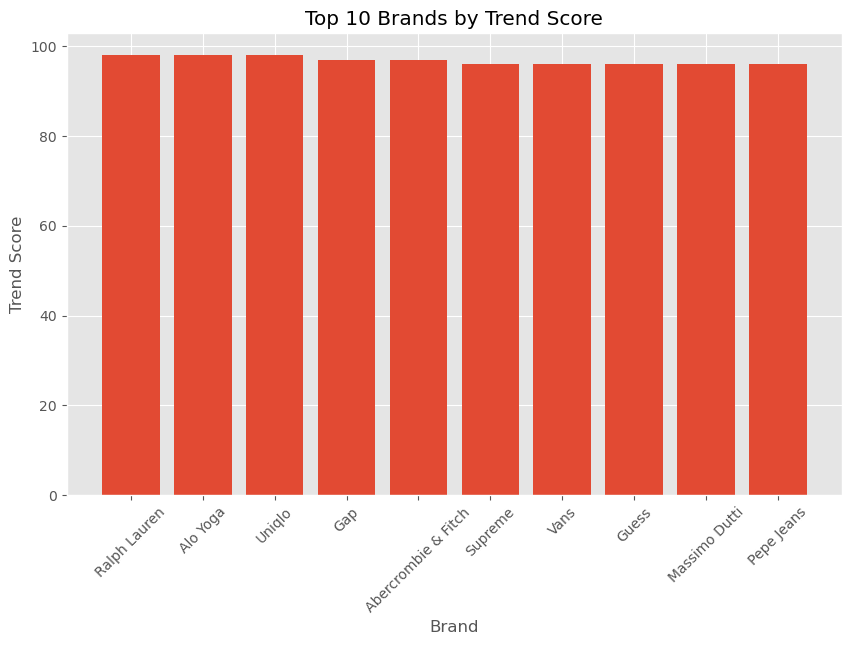

In [5]:
top_trend = df.sort_values(
    by="Trend_Score",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top_trend["Brand"],
    top_trend["Trend_Score"]
)

plt.title("Top 10 Brands by Trend Score")

plt.xlabel("Brand")

plt.ylabel("Trend Score")

plt.xticks(rotation=45)

plt.show()

# Top 10 Collaboration Scores

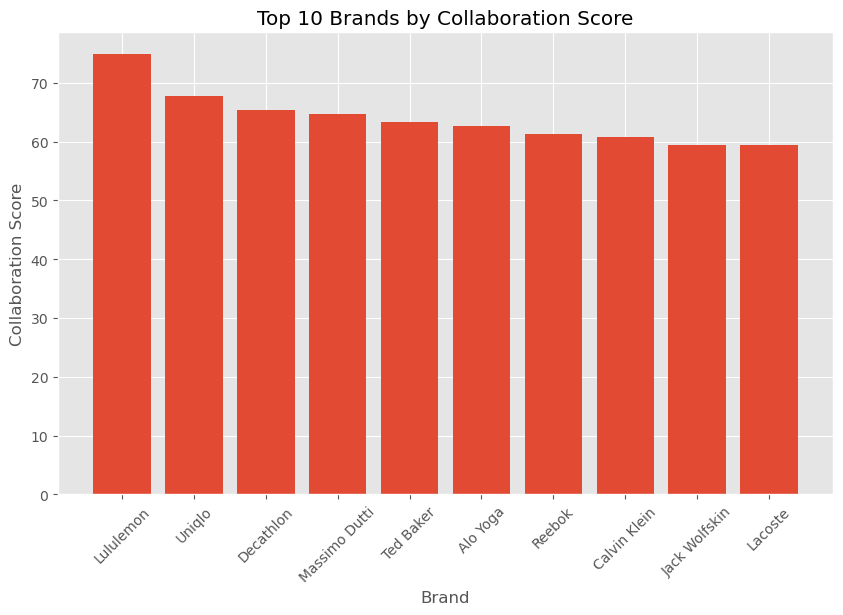

In [6]:
top_collab = df.sort_values(
    by="Collaboration_Score",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top_collab["Brand"],
    top_collab["Collaboration_Score"]
)

plt.title("Top 10 Brands by Collaboration Score")

plt.xlabel("Brand")

plt.ylabel("Collaboration Score")

plt.xticks(rotation=45)

plt.show()

# Sustainability Distribution

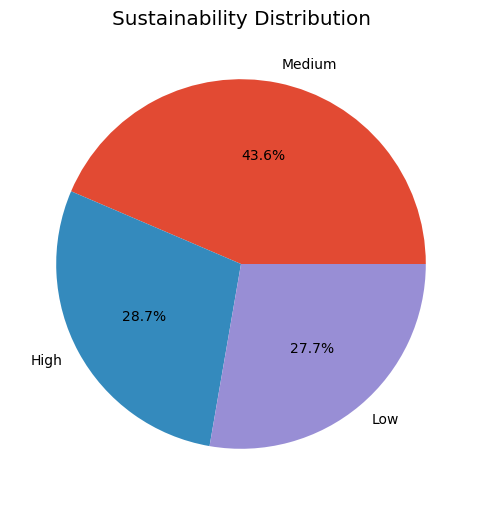

In [7]:
plt.figure(figsize=(6,6))

df["Sustainability"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Sustainability Distribution")

plt.show()

# Brand Category Distribution

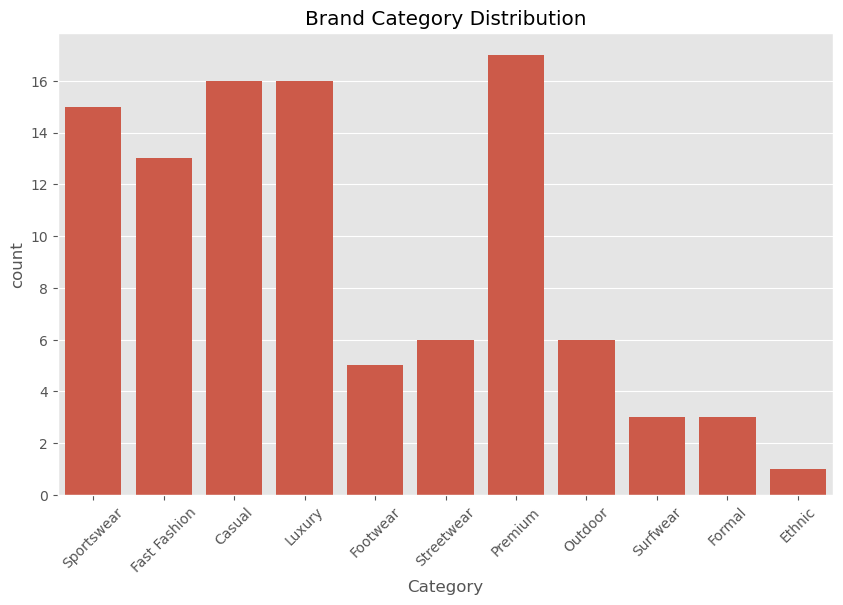

In [8]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Category"
)

plt.xticks(rotation=45)

plt.title("Brand Category Distribution")

plt.show()

 # Followers vs Engagement

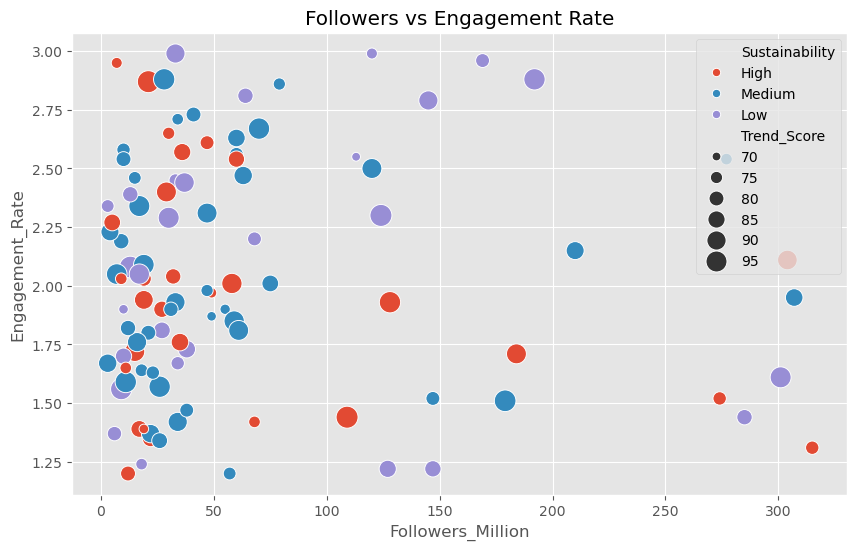

In [9]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Followers_Million",
    y="Engagement_Rate",
    hue="Sustainability",
    size="Trend_Score",
    sizes=(40,250)
)

plt.title("Followers vs Engagement Rate")
plt.show()

# Correlation Heatmap

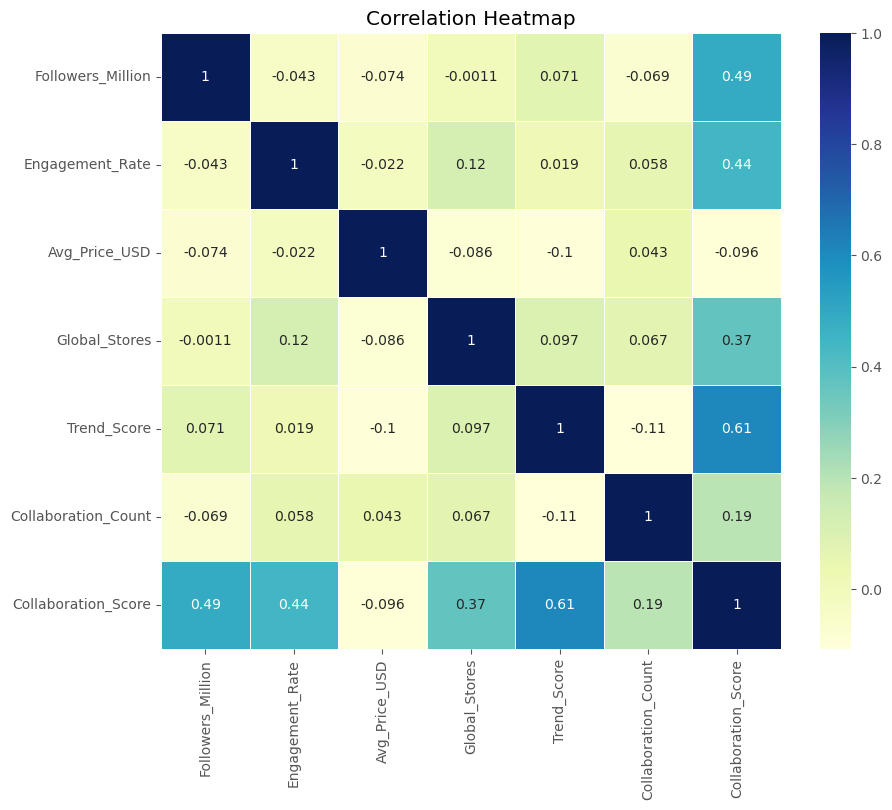

In [10]:
plt.figure(figsize=(10,8))

corr = df[[
    "Followers_Million",
    "Engagement_Rate",
    "Avg_Price_USD",
    "Global_Stores",
    "Trend_Score",
    "Collaboration_Count",
    "Collaboration_Score"
]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="YlGnBu",
    linewidths=.5
)

plt.title("Correlation Heatmap")
plt.show()

# Top Countries by Number of Brands

C:\Users\rishi\AppData\Local\Temp\ipykernel_28812\506456516.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


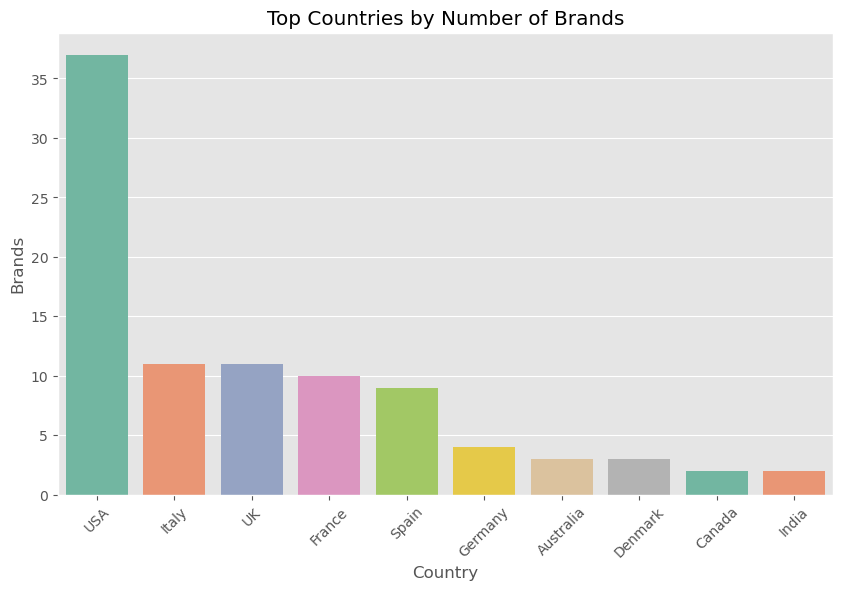

In [11]:
country = df["Country"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=country.index,
    y=country.values,
    palette="Set2"
)

plt.xticks(rotation=45)
plt.title("Top Countries by Number of Brands")
plt.xlabel("Country")
plt.ylabel("Brands")
plt.show()

# Price Distribution

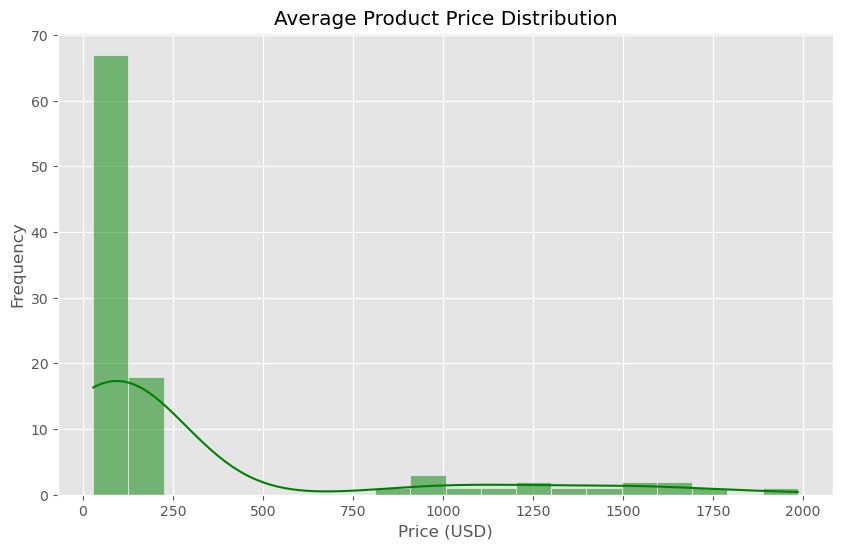

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Avg_Price_USD"],
    bins=20,
    kde=True,
    color="green"
)

plt.title("Average Product Price Distribution")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.show()

# Average Trend Score by Category

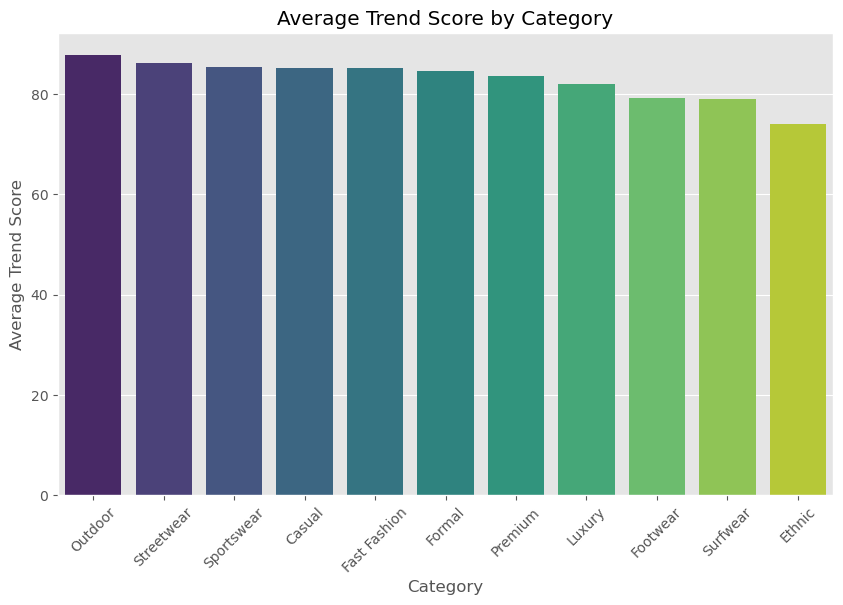

In [14]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=avg_trend.index,
    y=avg_trend.values,
    hue=avg_trend.index,
    palette="viridis",
    legend=False
)

plt.title("Average Trend Score by Category")
plt.xlabel("Category")
plt.ylabel("Average Trend Score")
plt.xticks(rotation=45)

plt.show()

# Top 10 Most Followed Brands

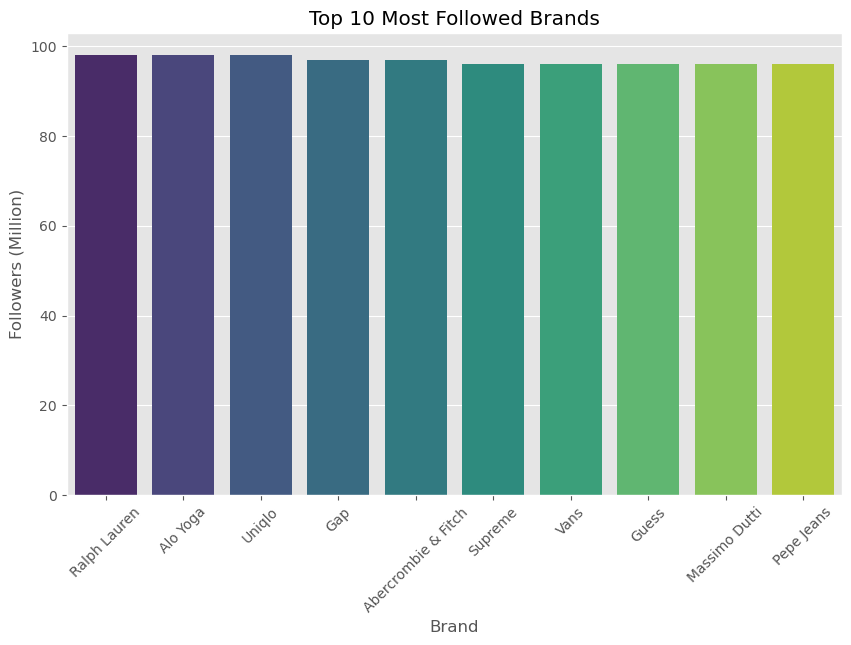

In [16]:
top_followers = (
    df.sort_values(
        by="Followers_Million",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_trend,
    x="Brand",
    y="Trend_Score",
    hue="Brand",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Most Followed Brands")
plt.xlabel("Brand")
plt.ylabel("Followers (Million)")
plt.xticks(rotation=45)

plt.show()